# UCInsure — Flood Risk Model

**From `src/models/README.md`:** Add all the models here.

---

## Purpose
This notebook implements the **flood risk** model for the UCInsure climate-driven insurance risk pipeline using **FEMA NFIP (National Flood Insurance Program)** claims data.

## What It Does
- **Ingest** — Fetches FEMA OpenFEMA NFIP claims via REST API and caches locally
- **Allowed columns** — Uses only a restricted set of privacy-safe columns
- **ML models** — Trains 3 classifiers (Random Forest, Gradient Boosting, Extra Trees) in parallel
- **Risk scoring** — Produces a normalized risk score in [0, 1] per region
- **Confidence** — Quantifies model confidence based on historical record density
- **Heatmaps** — Visualises flood damage caused and insurance claims across flood zones and geography

## Setup

Install dependencies:

    pip install numpy pandas scikit-learn joblib matplotlib seaborn

Run **Cell 2** first — installs packages, fetches/caches FEMA data, trains models.  
Run **Cell 3** — generates the damage caused / claims heatmaps.

## Data Source
- FEMA OpenFEMA API v2 — `FimaNfipClaims`
- Cached at `data/cache/FimaNfipClaimsV2.csv` after first run
- Sample size: 250,000 rows (configurable via `SAMPLE_ROWS`)

## Key Columns

| Column | Description |
|--------|-------------|
| `buildingDamageAmount` | Total flood damage to the building ($) |
| `amountPaidOnBuildingClaim` | Insurance payout for building ($) |
| `amountPaidOnContentsClaim` | Insurance payout for contents ($) |
| `floodZoneCurrent` | FEMA flood zone designation |
| `latitude` / `longitude` | Property coordinates |
| `yearOfLoss` | Year the flood loss occurred |


In [2]:
import subprocess, sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "numpy", "pandas", "scikit-learn", "joblib", "matplotlib", "seaborn"
])

import json
import math
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

DATA_URL = "https://www.fema.gov/api/open/v2/FimaNfipClaims"
DATA_CACHE_PATH = Path("data") / "cache" / "FimaNfipClaimsV2.csv"
MODEL_CACHE_DIR = Path("data") / "cache" / "models"

ALLOWED_COLUMNS = (
    "reportedCity",
    "reportedZipCode",
    "latitude",
    "longitude",
    "floodEvent",
    "dateOfLoss",
    "yearOfLoss",
    "floodZoneCurrent",
    "waterDepth",
    "numberOfFloorsInTheInsuredBuilding",
    "occupancyType",
    "primaryResidenceIndicator",
    "buildingPropertyValue",
    "contentsPropertyValue",
    "amountPaidOnBuildingClaim",
    "amountPaidOnContentsClaim",
    "buildingDamageAmount",
)

SAMPLE_ROWS = 250_000
RANDOM_STATE = 42

# ── Fetch & cache FEMA NFIP claims data ──────────────────────────────────────
def fetch_fema_page(skip: int, top: int = 10_000) -> list[dict]:
    """Fetch one page of FEMA NFIP claims via the OpenFEMA REST API."""
    params = urlencode({
        "$select": ",".join(ALLOWED_COLUMNS),
        "$top": top,
        "$skip": skip,
        "$format": "json",
    })
    url = f"{DATA_URL}?{params}"
    req = Request(url, headers={"User-Agent": "UCInsure/1.0"})
    with urlopen(req, timeout=60) as resp:
        return json.loads(resp.read())["FimaNfipClaims"]

def fetch_and_cache_fema_data() -> None:
    """Fetch SAMPLE_ROWS records from FEMA API in parallel pages and cache to CSV."""
    DATA_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    page_size = 10_000
    n_pages = math.ceil(SAMPLE_ROWS / page_size)
    skips = [i * page_size for i in range(n_pages)]

    print(f"Fetching {SAMPLE_ROWS:,} rows from FEMA API across {n_pages} pages …")
    with ThreadPoolExecutor(max_workers=8) as pool:
        pages = list(pool.map(lambda s: fetch_fema_page(s, page_size), skips))

    records = [row for page in pages for row in page]
    df = pd.DataFrame(records)
    # Keep only allowed columns that are present in the response
    cols = [c for c in ALLOWED_COLUMNS if c in df.columns]
    df[cols].to_csv(DATA_CACHE_PATH, index=False)
    print(f"Cached {len(df):,} rows → {DATA_CACHE_PATH}")

if not DATA_CACHE_PATH.exists():
    fetch_and_cache_fema_data()
else:
    print(f"Cache already exists at {DATA_CACHE_PATH} — skipping fetch.")


Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Fetching 250,000 rows from FEMA API across 25 pages …
Cached 250,000 rows → data/cache/FimaNfipClaimsV2.csv
Loaded 250,000 total rows | 69,506 rows from 2000+


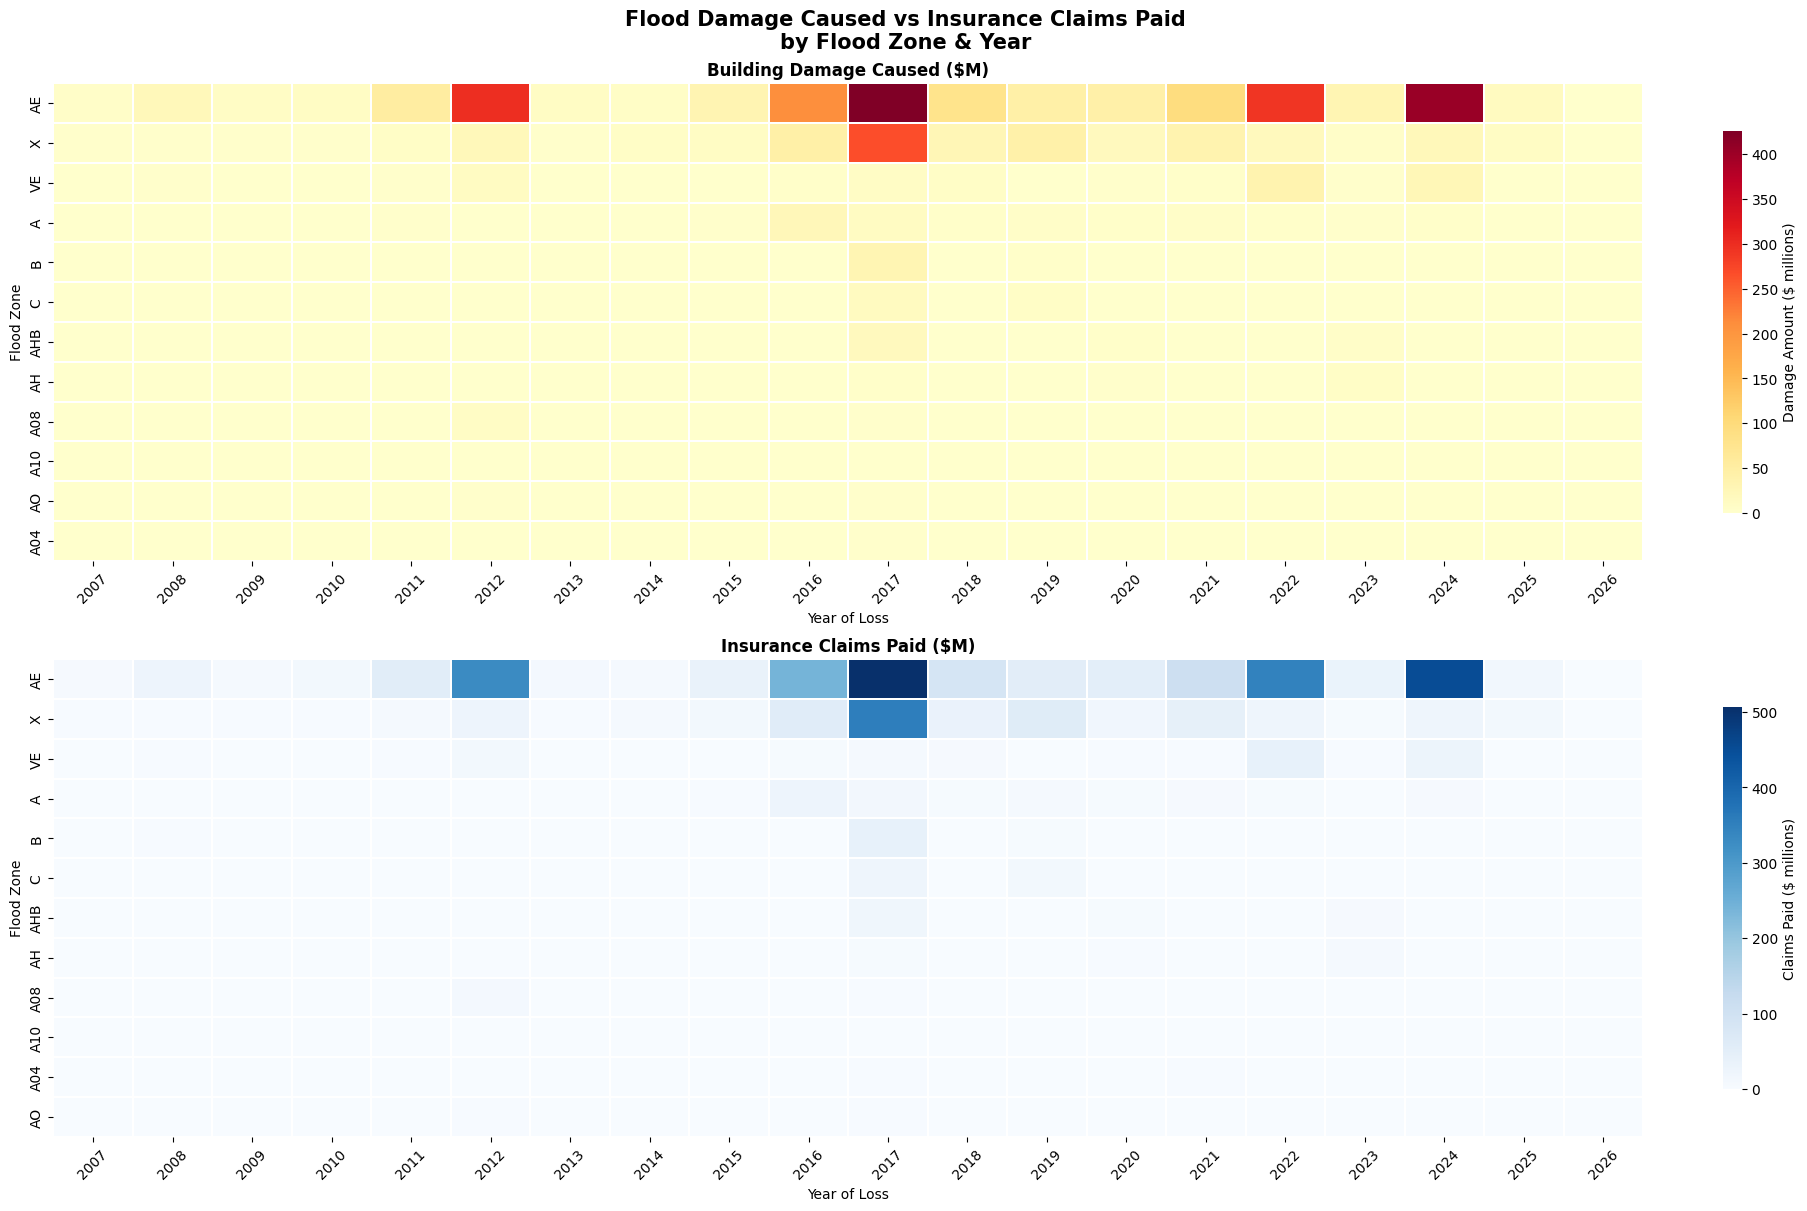

Saved → heatmap_damage_vs_claims_zone_year.png


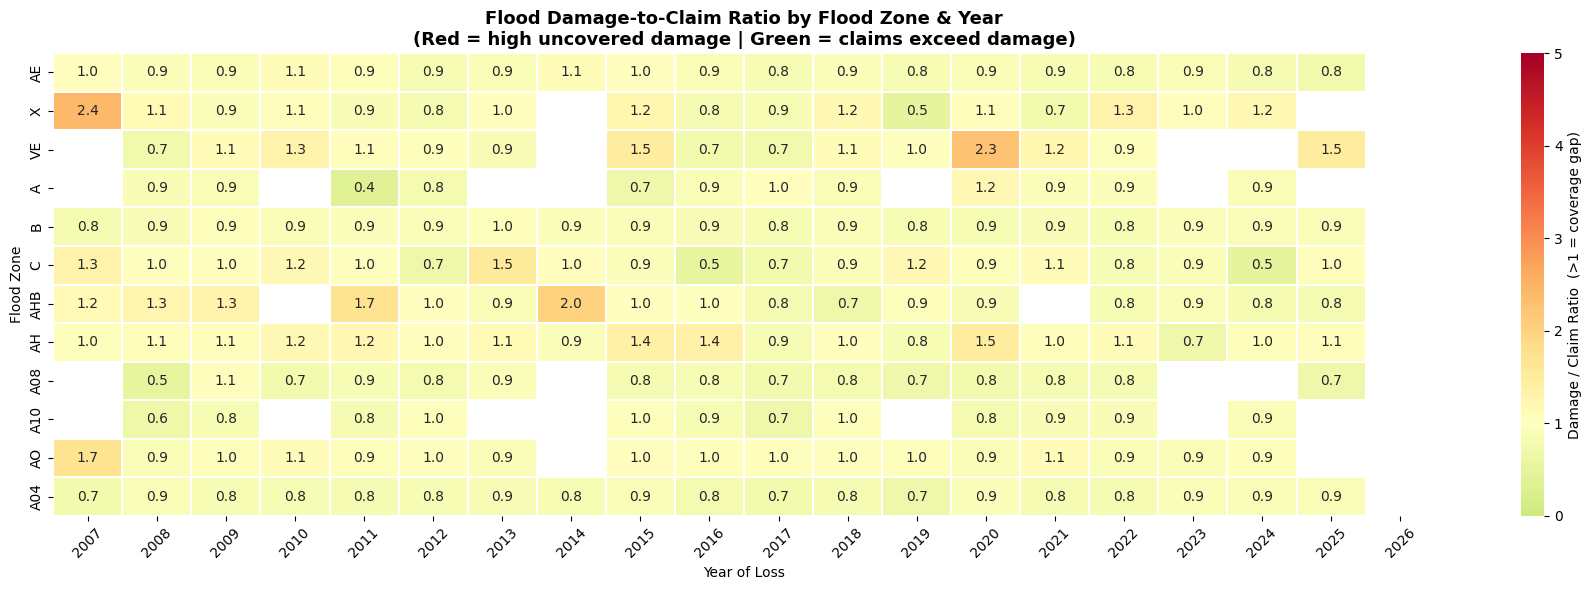

Saved → heatmap_damage_claim_ratio.png


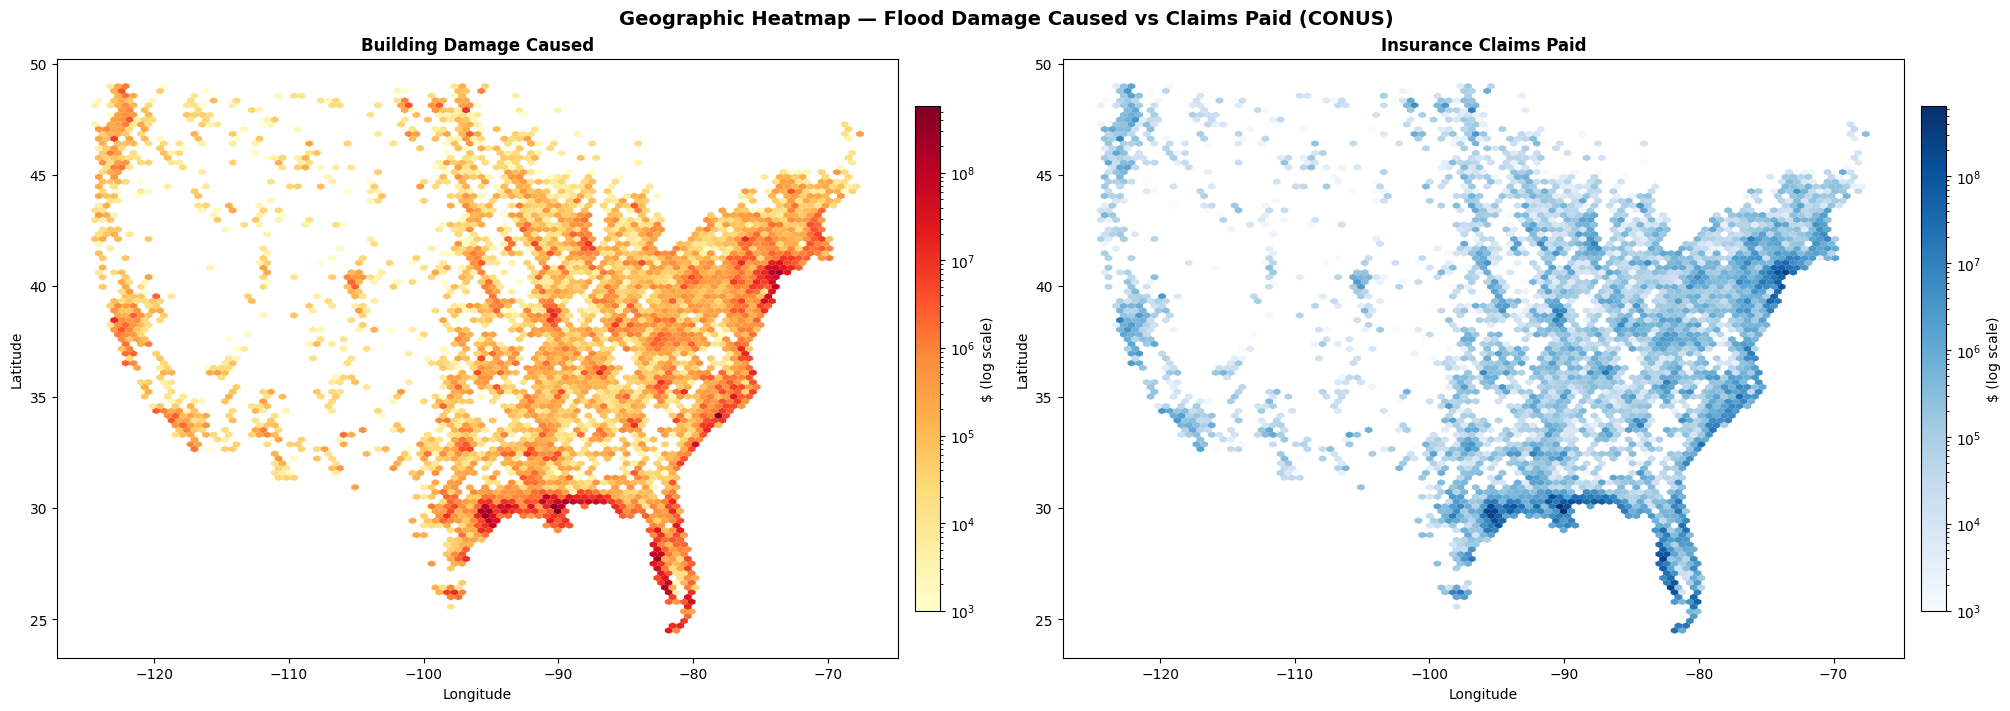

Saved → heatmap_geo_damage_vs_claims.png


In [5]:

# ── Heatmaps: Flood Damage Caused vs Claims (self-contained) ───────────────────

import json
import math
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Fallbacks if Cell 2 was not run after kernel restart
DATA_URL = globals().get("DATA_URL", "https://www.fema.gov/api/open/v2/FimaNfipClaims")
DATA_CACHE_PATH = globals().get("DATA_CACHE_PATH", Path("data") / "cache" / "FimaNfipClaimsV2.csv")
ALLOWED_COLUMNS = globals().get(
    "ALLOWED_COLUMNS",
    (
        "reportedCity",
        "reportedZipCode",
        "latitude",
        "longitude",
        "floodEvent",
        "dateOfLoss",
        "yearOfLoss",
        "floodZoneCurrent",
        "waterDepth",
        "numberOfFloorsInTheInsuredBuilding",
        "occupancyType",
        "primaryResidenceIndicator",
        "buildingPropertyValue",
        "contentsPropertyValue",
        "amountPaidOnBuildingClaim",
        "amountPaidOnContentsClaim",
        "buildingDamageAmount",
    ),
)
SAMPLE_ROWS = globals().get("SAMPLE_ROWS", 250_000)

def fetch_fema_page(skip: int, top: int = 10_000):
    params = urlencode(
        {
            "$select": ",".join(ALLOWED_COLUMNS),
            "$top": top,
            "$skip": skip,
            "$format": "json",
        }
    )
    req = Request(f"{DATA_URL}?{params}", headers={"User-Agent": "UCInsure/1.0"})
    with urlopen(req, timeout=60) as resp:
        return json.loads(resp.read()).get("FimaNfipClaims", [])

def fetch_and_cache_fema_data():
    DATA_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    page_size = 10_000
    n_pages = math.ceil(SAMPLE_ROWS / page_size)
    skips = [i * page_size for i in range(n_pages)]

    print(f"Fetching {SAMPLE_ROWS:,} rows from FEMA API across {n_pages} pages …")
    with ThreadPoolExecutor(max_workers=8) as pool:
        pages = list(pool.map(lambda s: fetch_fema_page(s, page_size), skips))

    records = [row for page in pages for row in page]
    df_fetch = pd.DataFrame(records)
    cols = [c for c in ALLOWED_COLUMNS if c in df_fetch.columns]
    if not cols:
        raise RuntimeError("No expected FEMA columns returned; cannot build cache.")
    df_fetch[cols].to_csv(DATA_CACHE_PATH, index=False)
    print(f"Cached {len(df_fetch):,} rows → {DATA_CACHE_PATH}")

# Ensure cache exists
if not DATA_CACHE_PATH.exists():
    fetch_and_cache_fema_data()

# Robust read: only columns actually present in CSV
csv_cols = pd.read_csv(DATA_CACHE_PATH, nrows=0).columns.tolist()
use_cols = [c for c in ALLOWED_COLUMNS if c in csv_cols]
df = pd.read_csv(DATA_CACHE_PATH, usecols=use_cols, low_memory=False)

for col in [
    "amountPaidOnBuildingClaim",
    "amountPaidOnContentsClaim",
    "buildingDamageAmount",
    "yearOfLoss",
    "latitude",
    "longitude",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["amountPaidOnBuildingClaim"] = df.get("amountPaidOnBuildingClaim", 0).fillna(0)
df["amountPaidOnContentsClaim"] = df.get("amountPaidOnContentsClaim", 0).fillna(0)
df["buildingDamageAmount"] = df.get("buildingDamageAmount", 0).fillna(0)
df["totalClaim"] = df["amountPaidOnBuildingClaim"] + df["amountPaidOnContentsClaim"]

if "floodZoneCurrent" not in df.columns:
    df["floodZoneCurrent"] = np.nan
if "yearOfLoss" not in df.columns:
    df["yearOfLoss"] = np.nan

df_yr = df[(df["yearOfLoss"] >= 2000) & df["floodZoneCurrent"].notna()].copy()
print(f"Loaded {len(df):,} total rows | {len(df_yr):,} rows from 2000+")

def zone_year_pivot(metric_col, n_zones=12, n_years=20):
    piv = (
        df_yr.groupby(["floodZoneCurrent", "yearOfLoss"])[metric_col]
        .sum()
        .unstack("yearOfLoss")
        .fillna(0)
    )
    if piv.empty:
        return pd.DataFrame()
    top = piv.sum(axis=1).nlargest(min(n_zones, len(piv))).index
    return piv.loc[top].iloc[:, -n_years:]

# Plot 1 & 2
dmg_piv = zone_year_pivot("buildingDamageAmount")
claim_piv = zone_year_pivot("totalClaim")

if not dmg_piv.empty and not claim_piv.empty:
    fig, axes = plt.subplots(2, 1, figsize=(18, 12), constrained_layout=True)
    fig.suptitle(
        "Flood Damage Caused vs Insurance Claims Paid\nby Flood Zone & Year",
        fontsize=15,
        fontweight="bold",
    )

    for ax, piv, title, cmap, label in [
        (axes[0], dmg_piv, "Building Damage Caused ($M)", "YlOrRd", "Damage Amount ($ millions)"),
        (axes[1], claim_piv, "Insurance Claims Paid ($M)", "Blues", "Claims Paid ($ millions)"),
    ]:
        sns.heatmap(
            piv / 1e6,
            cmap=cmap,
            linewidths=0.3,
            linecolor="white",
            annot=False,
            cbar_kws={"label": label, "shrink": 0.8},
            ax=ax,
        )
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Year of Loss")
        ax.set_ylabel("Flood Zone")
        ax.tick_params(axis="x", rotation=45)

    plt.savefig("heatmap_damage_vs_claims_zone_year.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → heatmap_damage_vs_claims_zone_year.png")

    # Plot 3: Damage / Claims ratio heatmap
    common_cols = dmg_piv.columns.intersection(claim_piv.columns)
    dmg_aligned = dmg_piv[common_cols]
    claim_aligned = claim_piv[common_cols]

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio_piv = np.where(claim_aligned > 0, dmg_aligned / claim_aligned, np.nan)
    ratio_piv = pd.DataFrame(ratio_piv, index=dmg_aligned.index, columns=dmg_aligned.columns)

    fig, ax = plt.subplots(figsize=(18, 6))
    sns.heatmap(
        ratio_piv,
        cmap="RdYlGn_r",
        center=1.0,
        vmin=0,
        vmax=5,
        linewidths=0.3,
        linecolor="white",
        annot=True,
        fmt=".1f",
        cbar_kws={"label": "Damage / Claim Ratio  (>1 = coverage gap)"},
        ax=ax,
    )
    ax.set_title(
        "Flood Damage-to-Claim Ratio by Flood Zone & Year\n"
        "(Red = high uncovered damage | Green = claims exceed damage)",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Year of Loss")
    ax.set_ylabel("Flood Zone")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig("heatmap_damage_claim_ratio.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → heatmap_damage_claim_ratio.png")
else:
    print("Insufficient zone/year data to plot zone heatmaps.")

# Plot 4: Geographic hexbin
geo = df.dropna(subset=["latitude", "longitude"]).copy()
geo = geo[geo["latitude"].between(24, 50) & geo["longitude"].between(-130, -65)]

if not geo.empty:
    fig, axes = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)
    fig.suptitle(
        "Geographic Heatmap — Flood Damage Caused vs Claims Paid (CONUS)",
        fontsize=14,
        fontweight="bold",
    )

    for ax, col, title, cmap in [
        (axes[0], "buildingDamageAmount", "Building Damage Caused", "YlOrRd"),
        (axes[1], "totalClaim", "Insurance Claims Paid", "Blues"),
    ]:
        # keep positive values for log normalization
        geo_col = geo[geo[col] > 0]
        if geo_col.empty:
            ax.set_title(f"{title} (no positive values)")
            ax.set_xlabel("Longitude")
            ax.set_ylabel("Latitude")
            continue

        h = ax.hexbin(
            geo_col["longitude"],
            geo_col["latitude"],
            C=geo_col[col],
            reduce_C_function=np.sum,
            gridsize=100,
            cmap=cmap,
            norm=mcolors.LogNorm(vmin=1e3),
            linewidths=0.05,
        )
        cb = fig.colorbar(h, ax=ax, fraction=0.03, pad=0.02)
        cb.set_label("$ (log scale)")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    plt.savefig("heatmap_geo_damage_vs_claims.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → heatmap_geo_damage_vs_claims.png")
else:
    print("No valid geo points for hexbin map.")